In [1]:
# XGBoost & SHAP Model

! pip  install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 45.5 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.1/342.1 MB 52.9 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]


In [2]:
import xgboost
print(xgboost.__version__)

3.2.0


In [3]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings. filterwarnings('ignore')

In [ ]:
dataset = load_breast_cancer()
X_features = dataset.data
y_label = dataset.target

cancer_df = pd.DataFrame(data=X_features, columns=dataset.feature_names)

cancer_df['target'] = y_label
cancer_df.head(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0


In [6]:
# 타겟의 0과 1이 각각 몇 개 있는지 출력하여 데이터 분포 확인 (0: 악성 / 1: 양성)
cancer_df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [7]:
X_features = cancer_df.iloc[:, :-1]         # feature 컬럼만 선택하기 위해 마지막 target 컬럼 제외한 모든 컬럼값이 입력 데이터로 사용
y_label = cancer_df.iloc[:, -1]             # 마지막 컬럼 target만 선택해서 label 데이터로 사용

In [8]:
# 학습 데이터 분할 (학습 : 80%, 테스트 : 20%)
X_train, X_test, y_train, y_test = train_test_split(
  X_features, y_label, test_size = 0.2, random_state=156
)

# 전체 데이터에서 학습 90%, 테스트 10% 비율로 분리하고 모델 튜닝시 활용
X_tr, X_val, y_tr, y_val = train_test_split(
  X_train, y_train, test_size = 0.1, random_state=156
)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


In [9]:
# xgboost가 계산을 최적화하기 위해 사용하는 DMatrix 구조로 학습 데이터를 변환
dtr = xgb.DMatrix(data=X_tr, label=y_tr)
dval = xgb.DMatrix(data=X_val, label=y_val)
dtest = xgb.DMatrix(data=X_test, label=y_test)

In [10]:
# 모델 학습에 필요한 하이퍼파라미터 설정
params = {
  'max_depth' : 3,                    # 트리의 깊이를 3개로 제한해서 과적합을 방지
  'eta' : 0.5,                        # learning rate를 설정하여 한번의 학습 단계에서 조정되는 크기 설정
  'object' : 'binary:logistic',       # 이진 분류 문제이므로 로지스틱 함수를 사용해서 확률로 예측
  'eval_metric' : 'logloss'           # 평가 지표 : 로그손실(logloss)을 사용
}

num_rounds = 400                      # 최데 boosting 반복 횟수 정의

In [11]:
# 모델 설정

eval_list = [(dtr, 'train'), (dval, 'eval')]

xgb_model = xgb.train(
  params=params,
  dtrain=dtr,
  num_boost_round=num_rounds,
  early_stopping_rounds=50,         # 학습시, 모델 성능이 개선되었거나, 계속  개선되지 않으면 학습을 조기 종료
  evals=eval_list
)

[0]	train-logloss:0.30866	eval-logloss:0.42334
[1]	train-logloss:0.16557	eval-logloss:0.31539
[2]	train-logloss:0.09379	eval-logloss:0.27291
[3]	train-logloss:0.05932	eval-logloss:0.26891
[4]	train-logloss:0.04123	eval-logloss:0.27955
[5]	train-logloss:0.03183	eval-logloss:0.27551
[6]	train-logloss:0.02470	eval-logloss:0.20586
[7]	train-logloss:0.02144	eval-logloss:0.19698
[8]	train-logloss:0.01710	eval-logloss:0.20256
[9]	train-logloss:0.01592	eval-logloss:0.20337
[10]	train-logloss:0.01422	eval-logloss:0.21869
[11]	train-logloss:0.01374	eval-logloss:0.21049
[12]	train-logloss:0.01367	eval-logloss:0.21228
[13]	train-logloss:0.01232	eval-logloss:0.19498
[14]	train-logloss:0.01041	eval-logloss:0.19772
[15]	train-logloss:0.00962	eval-logloss:0.19559
[16]	train-logloss:0.00959	eval-logloss:0.19556
[17]	train-logloss:0.00814	eval-logloss:0.19660
[18]	train-logloss:0.00795	eval-logloss:0.19181
[19]	train-logloss:0.00776	eval-logloss:0.19380
[20]	train-logloss:0.00719	eval-logloss:0.19341
[2

In [13]:
# 테스트 데이터셋에 대해 모델이 예측한 확률값
pred_probs = xgb_model.predict(dtest)

print('predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시')
print(np.round(pred_probs[:10], 3))

# 예측된 확률값이 0.5보다 크면 양성(1), 그렇지 않으면 악성(0)으로 판단
preds = [1 if x > 0.5 else 0 for x in pred_probs]

print('예측한 10개만 표시 : ', preds[:10])


predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시
[0.766 0.092 0.768 0.109 0.993 0.978 1.044 0.995 1.04  0.003]
예측한 10개만 표시 :  [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
  confusion = confusion_matrix(y_test, pred)
  accuracy = accuracy_score(y_test, pred)
  precision = precision_score(y_test, pred)
  recall = recall_score(y_test, pred)
  f1 = f1_score(y_test, pred)
  roc_auc = roc_auc_score(y_test, pred_proba)

  print('오차행렬')
  print(confusion)

  print(
      '정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, '
      'F1: {3:.4f}, AUC: {4:.4f}'
      .format(accuracy, precision, recall, f1, roc_auc)
  )
get_clf_eval(y_test, preds, pred_probs)

오차행렬
[[36  1]
 [ 2 75]]
정확도: 0.9737, 정밀도: 0.9868, 재현율: 0.9740, F1: 0.9804, AUC: 0.9972


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

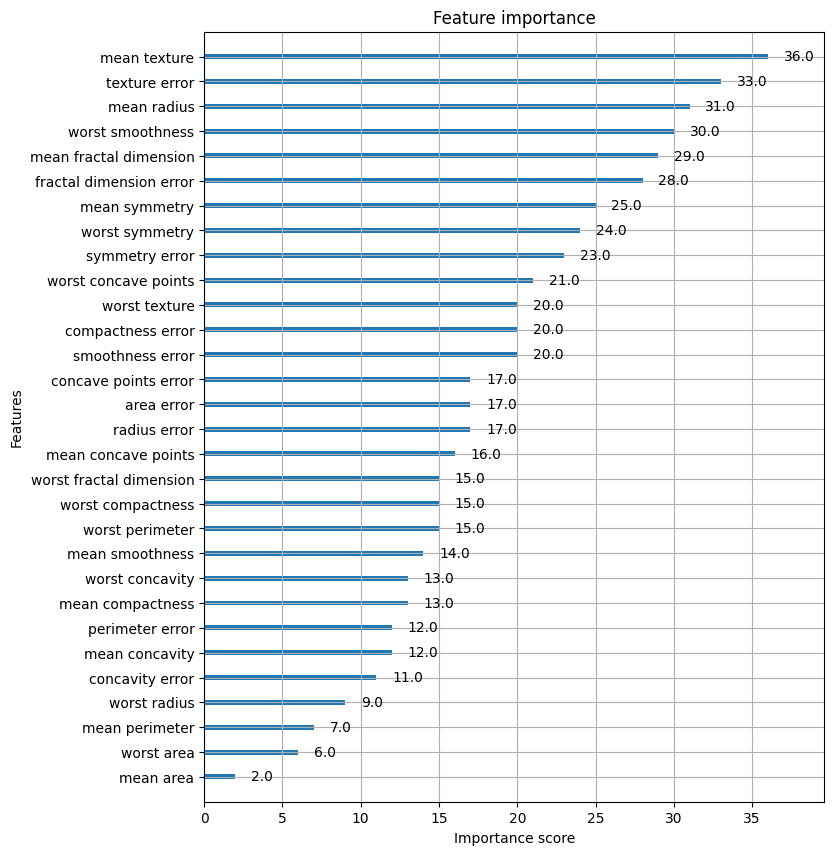

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

# feature importance 시각화
fig, ax = plt.subplots(figsize=(8,10))
plot_importance(xgb_model, ax=ax)